## Notebook 05b - Robustness check (betweenness attack)
Núria Pascual Salas

**Content:** Validation of the attack criterion. Repeats the fragility analysis using
betweenness centrality (instead of PageRank) to rank players in the targeted attack,
and correlates the resulting fragility with the PageRank-based fragility from notebook
05 to check that the ranking is robust to the choice of centrality. Betweenness treats
edge weights as distances, so pass counts are inverted (1/passes) before computing,
making high-traffic connections short paths.

**Inputs:** fragility_per_team.csv (from notebook 05).

**Outputs:**
- outputs/csv/fragility_per_team_betweenness.csv
- outputs/figures/all_degradation_curves_betweenness.png

**Used in:** Chapter 4 (robustness check on the attack criterion).

In [1]:
from utils import *
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pandas as pd
from scipy.stats import pearsonr


FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

### 1. Targeted attack function (betweenness-based node removal)

In [2]:
def targeted_attack_betweenness(G):
    """
    Remove players in betweenness-centrality descending order.
    Edge weights are inverted (1/passes) so that high-traffic edges = short distances.
    
    Returns a list of efficiency values after each removal.
    Index 0 = original network, index k = after removing top-k players.
    """
    G_work = G.copy()
    
    if G_work.number_of_nodes() == 0:
        return []
    
    eff_curve = [nx.global_efficiency(G_work.to_undirected())]
    
    while G_work.number_of_nodes() > 1:
        # Invert weights for betweenness: more passes -> shorter distance
        G_inv = G_work.copy()
        for u, v, d in G_inv.edges(data=True):
            d['weight'] = 1.0 / d['weight']
        
        try:
            bt = nx.betweenness_centrality(G_inv, weight='weight')
        except Exception:
            break
        
        # If all betweenness values are 0 (very small network), stop
        if all(v == 0 for v in bt.values()):
            # Remove a random node to keep going
            most_central = list(G_work.nodes())[0]
        else:
            most_central = max(bt, key=bt.get)
        
        G_work.remove_node(most_central)
        
        if G_work.number_of_nodes() > 0:
            eff_curve.append(nx.global_efficiency(G_work.to_undirected()))
        else:
            eff_curve.append(0.0)
    
    return eff_curve


### 2. Degrade each team's network and compute fragility

In [3]:
robustness_results = {}

for team_id, team_name in all_teams.items():
    print(f"Computing robustness for {team_name}...")
    G, n_matches = build_consolidated_network(team_id, team_name, zip_path, folder_laliga)
    
    if G.number_of_nodes() < 5:
        print(f"  Skipped (network too small)")
        continue
    
    targeted_curve = targeted_attack_betweenness(G)
    random_curve   = random_attack(G, n_simulations=50)
    
    robustness_results[team_name] = {
        'team_id':        team_id,
        'targeted_curve': targeted_curve,
        'random_curve':   random_curve,
        'n_nodes':        G.number_of_nodes(),
    }
    print(f"  Done | {G.number_of_nodes()} players")

Computing robustness for Deportivo Alavés...
  Done | 29 players
Computing robustness for Granada...
  Done | 40 players
Computing robustness for Barcelona...
  Done | 29 players
Computing robustness for Almería...
  Done | 35 players
Computing robustness for Sevilla...
  Done | 35 players
Computing robustness for Cádiz...
  Done | 33 players
Computing robustness for Girona...
  Done | 25 players
Computing robustness for Athletic Club...
  Done | 27 players
Computing robustness for Real Sociedad...
  Done | 31 players
Computing robustness for Mallorca...
  Done | 25 players
Computing robustness for Real Betis...
  Done | 35 players
Computing robustness for Atlético Madrid...
  Done | 27 players
Computing robustness for Villarreal...
  Done | 32 players
Computing robustness for Celta Vigo...
  Done | 31 players
Computing robustness for Valencia...
  Done | 30 players
Computing robustness for Las Palmas...
  Done | 29 players
Computing robustness for Osasuna...
  Done | 29 players
Comput

### 3. Save fragility per team

In [4]:
fragility_table = []
for team_name, data in robustness_results.items():
    frag = compute_fragility(data['targeted_curve'], data['random_curve'])
    fragility_table.append({
        'team':      team_name,
        'team_id':   data['team_id'],
        'fragility': round(frag, 4),
        'n_players': data['n_nodes'],
    })

df_fragility = pd.DataFrame(fragility_table).sort_values('fragility', ascending=False)
df_fragility.to_csv(f'{CSV_DIR}/fragility_per_team_betweenness.csv', index=False)
print(df_fragility.to_string(index=False))

            team  team_id  fragility  n_players
         Granada     1049     0.5178         40
Deportivo Alavés      206     0.4578         29
         Osasuna      422     0.4180         29
        Valencia      207     0.3818         30
           Cádiz      552     0.3795         33
          Getafe      216     0.3791         32
   Real Sociedad      210     0.3595         31
      Real Betis      218     0.3491         35
     Real Madrid      220     0.3479         27
          Girona      211     0.3448         25
 Atlético Madrid      212     0.3441         27
      Las Palmas      208     0.3301         29
      Villarreal      222     0.3241         32
         Almería      403     0.3232         35
  Rayo Vallecano      360     0.2882         26
       Barcelona      217     0.2831         29
        Mallorca     1043     0.2575         25
         Sevilla      213     0.2523         35
   Athletic Club      215     0.2496         27
      Celta Vigo      209     0.2221    

### 4. Plot degradation curves

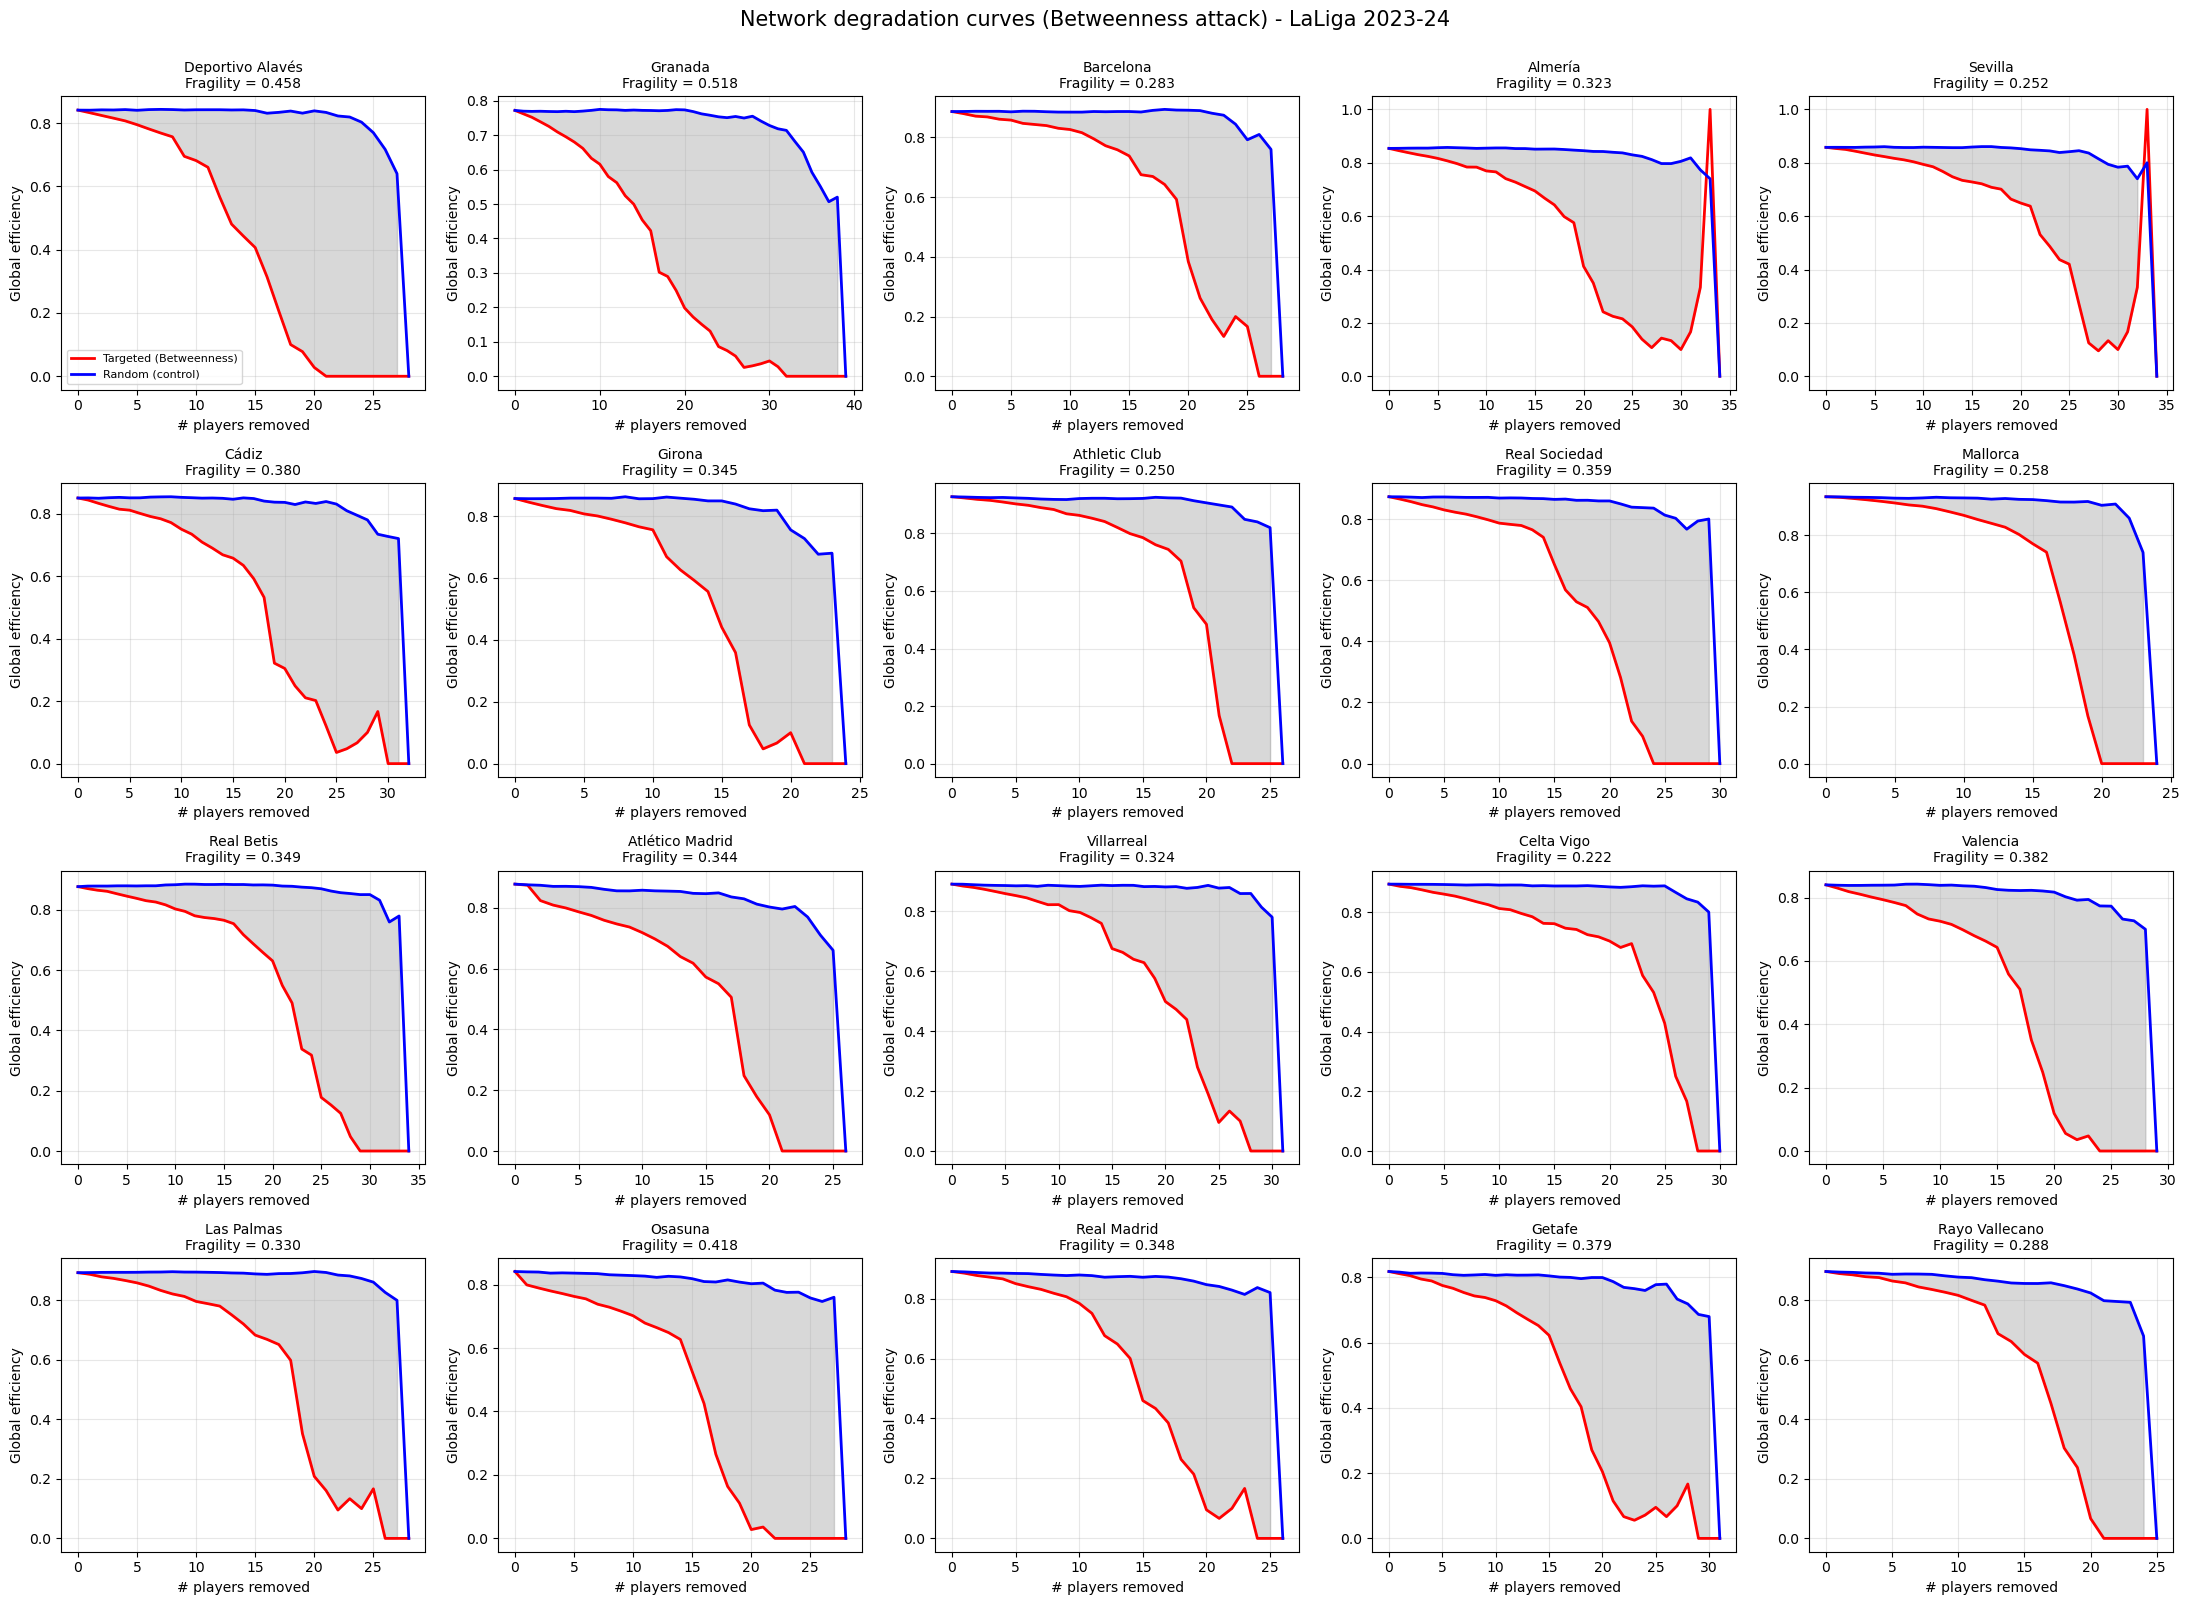

In [5]:
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for i, (team_name, data) in enumerate(robustness_results.items()):
    ax = axes[i]
    targeted = data['targeted_curve']
    random_  = data['random_curve']
    
    n = min(len(targeted), len(random_))
    x = list(range(n))
    
    ax.plot(x, targeted[:n], color='red',  linewidth=2, label='Targeted (Betweenness)')
    ax.plot(x, random_[:n],  color='blue', linewidth=2, label='Random (control)')
    ax.fill_between(x, targeted[:n], random_[:n],
                     where=np.array(random_[:n]) > np.array(targeted[:n]),
                     color='gray', alpha=0.3)
    
    frag = next(r['fragility'] for r in fragility_table if r['team'] == team_name)
    ax.set_title(f"{team_name}\nFragility = {frag:.3f}", fontsize=10)
    ax.set_xlabel('# players removed')
    ax.set_ylabel('Global efficiency')
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Network degradation curves (Betweenness attack) - LaLiga 2023-24',
             fontsize=15, y=1.00)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/all_degradation_curves_betweenness.png',
            dpi=120, bbox_inches='tight')
plt.show()

### 5. Methodological validation: PageRank vs Betweenness fragility


In [6]:
df_pr = pd.read_csv(f'{CSV_DIR}/fragility_per_team.csv')
df_pr = df_pr.rename(columns={'fragility': 'fragility_pagerank'})

df_bt = pd.read_csv(f'{CSV_DIR}/fragility_per_team_betweenness.csv')
df_bt = df_bt.rename(columns={'fragility': 'fragility_betweenness'})

df_merged = df_pr.merge(df_bt[['team', 'fragility_betweenness']], on='team')

r, p = pearsonr(df_merged['fragility_pagerank'],
                df_merged['fragility_betweenness'])

print(f"Correlation between PageRank and Betweenness fragility:")
print(f"  r = {r:+.3f}, p = {p:.4f}, n = {len(df_merged)}")
print()
if abs(r) > 0.9 and p < 0.001:
    print("Strong correlation confirms that the fragility ranking is")
    print("invariant under the choice of attack criterion.")

Correlation between PageRank and Betweenness fragility:
  r = +0.939, p = 0.0000, n = 20

Strong correlation confirms that the fragility ranking is
invariant under the choice of attack criterion.
